In [1]:
!pip install shap
!pip install xgboost

In [2]:
import numpy as np 
import pandas as pd 
import xgboost as xbg
import shap 
import matplotlib.pyplot as plt

/opt/miniconda3/envs/ml_month3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
shap.initjs()

In [4]:
# Dummy dataset 
n_samples = 2000
income = np.random.normal(loc=65000, scale=20000, size=n_samples).clip(20000, 200000)
credit_score = np.random.normal(loc=680, scale=50, size=n_samples).clip(300, 850)
dti = np.random.uniform(low=0.10, high=0.60, size=n_samples)
missed_payments = np.random.poisson(lam=0.5, size=n_samples).clip(0, 5)

In [5]:
zip_code = np.random.choice([90210, 90001], size=n_samples)
age = np.random.uniform(low=18, high=75, size=n_samples)

In [6]:
base_score = (credit_score / 850) * 0.4 + (income / 200000) * 0.3 - (dti * 0.2) - (missed_payments * 0.1)

In [7]:
age_penalty = np.where(age < 25, -0.15, 0)
zip_penalty = np.where(zip_code == 90001, -0.20, 0.10)

In [8]:
final_score = base_score + age_penalty + zip_penalty

In [9]:
threshold = np.median(final_score)
approved = (final_score > threshold).astype(int)


In [10]:

# 4. Create DataFrame
df = pd.DataFrame({
    'Income': np.round(income),
    'Credit_Score': np.round(credit_score),
    'Debt_to_Income': np.round(dti, 2),
    'Missed_Payments': missed_payments,
    'Age': np.round(age),
    'Zip_Code': zip_code,
    'Approved': approved
})

# Display a sample of the data and the overall approval rate
print(f"Dataset generated with {n_samples} applications.")
print(f"Overall Approval Rate: {df['Approved'].mean() * 100:.1f}%\n")
display(df.head())

Dataset generated with 2000 applications.
Overall Approval Rate: 50.0%



,Income,Credit_Score,Debt_to_Income,Missed_Payments,Age,Zip_Code,Approved
0,64906.0,692.0,0.13,0,33.0,90001,0
1,62745.0,673.0,0.38,1,69.0,90210,1
2,62920.0,689.0,0.17,0,21.0,90210,1
3,87044.0,647.0,0.44,1,60.0,90001,0
4,67346.0,685.0,0.33,1,64.0,90210,1


In [11]:
df["Approved"].mean()

np.float64(0.5)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score , accuracy_score

In [13]:
df['is_90001'] = (df['Zip_Code'] == 90001).astype(int)

In [14]:
X = df.drop(columns=['Approved','Zip_Code'])
y = df['Approved']

In [15]:
X_train,X_test,y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [16]:
model = xbg.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

In [17]:
model.fit(X_train,y_train)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [18]:
train_pred = model.predict(X_train)
test_preds = model.predict(X_test)

In [19]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_preds)

In [20]:
test_probs = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)

In [21]:
print("\n=== Model Performance ===")
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy:     {test_acc * 100:.2f}%")
print(f"Test AUC:          {test_auc:.4f}")


=== Model Performance ===
Training Accuracy: 99.94%
Test Accuracy:     97.00%
Test AUC:          0.9982


In [22]:
import itertools
import math

In [23]:
applicant_idx = X_test[X_test['is_90001'] == 1].index[0]

In [24]:
applicant = X_test.loc[[applicant_idx]].copy()

In [25]:
background = X_train.mean().to_frame().T

In [26]:
target_feature = 'is_90001'

In [27]:
other_features = [col for col in X_train.columns if col != target_feature]

In [28]:
M = len(X_train.columns)

In [29]:
def predict_subset(subset):
    # Start with the background (average) values
    synthetic_instance = background.copy()
    # Overwrite with the applicant's actual values only for features IN the subset
    for feature in subset:
        synthetic_instance[feature] = applicant[feature].values
    # Predict the probability of approval
    return model.predict_proba(synthetic_instance)[0, 1]

In [30]:
print(f"Calculating manual Shapley value for '{target_feature}'...")
print(f"Total features (M) = {M}. Subsets to evaluate = 2^{M-1} = {2**(M-1)}.\n")

Calculating manual Shapley value for 'is_90001'...
Total features (M) = 6. Subsets to evaluate = 2^5 = 32.



In [32]:
shapley_value = 0.0

In [33]:
for subset_size in range(len(other_features) + 1):
    for subset in itertools.combinations(other_features, subset_size):
        subset_list = list(subset)
        
        # Calculate marginal contribution: Prediction WITH feature - Prediction WITHOUT feature
        pred_without = predict_subset(subset_list)
        pred_with = predict_subset(subset_list + [target_feature])
        marginal_contribution = pred_with - pred_without
        
        # Calculate the Shapley weight: (|S|! * (|F| - |S| - 1)!) / |F|!
        S = len(subset_list)
        weight = (math.factorial(S) * math.factorial(M - S - 1)) / math.factorial(M)
        
        # Add the weighted marginal contribution
        shapley_value += weight * marginal_contribution

In [34]:
print(f"Applicant's actual '{target_feature}' value: {applicant[target_feature].values[0]}")
print(f"Exact Manual SHAP value for {target_feature}: {shapley_value:.4f}")

Applicant's actual 'is_90001' value: 1
Exact Manual SHAP value for is_90001: -0.9980


# USING SHap library 

In [35]:
explainer = shap.TreeExplainer(model)

In [36]:
# 2. Calculate SHAP values
shap_values = explainer(X_test)

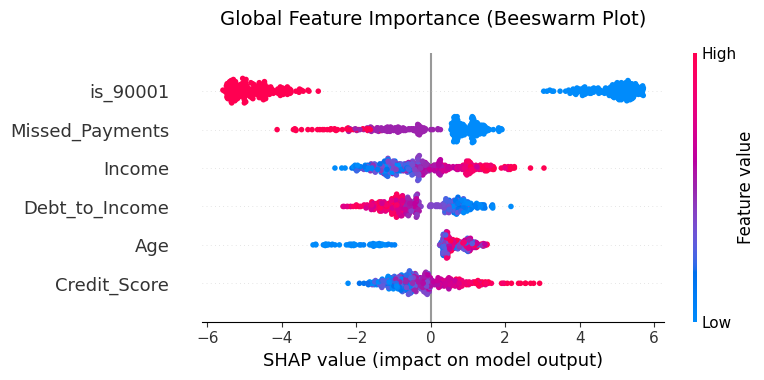

In [37]:
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance (Beeswarm Plot)", fontsize=14, pad=20)
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()

In [38]:
# 4. Local Waterfall Plot
applicant_iloc = X_test.index.get_loc(applicant_idx)

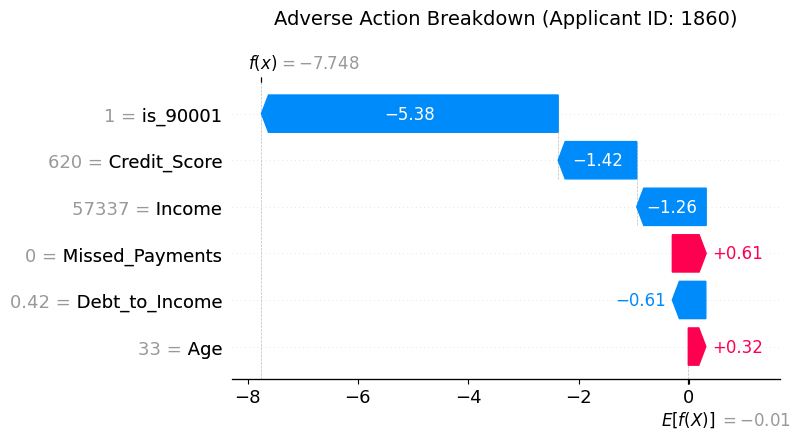

In [39]:
plt.figure(figsize=(10, 6))
plt.title(f"Adverse Action Breakdown (Applicant ID: {applicant_idx})", fontsize=14, pad=20)
# Use [0] safety catch just in case it's nested
shap.plots.waterfall(shap_values[applicant_iloc], show=False)
plt.tight_layout()
plt.show()